###Audio creation

In [ ]:
# ==============================
# INSTALL (if needed)
# ==============================
!pip install librosa soundfile tqdm --quiet

# ==============================
# IMPORTS
# ==============================
import os
import pandas as pd
import numpy as np
import librosa
import soundfile as sf
from tqdm import tqdm

# ==============================
# PATHS (EDIT IF NEEDED)
# ==============================
GTZAN_PATH = "/content/drive/MyDrive/archive/Data/genres_original"
TSV_PATH   = "/content/drive/MyDrive/archive/tsv"
OUT_PATH   = "/content/drive/MyDrive/archive/reconstructed_runs"

os.makedirs(OUT_PATH, exist_ok=True)

# ==============================
# PARAMETERS
# ==============================
SR = 22050
RUN_DURATION = 600  # seconds
TOTAL_SAMPLES = SR * RUN_DURATION

# ==============================
# HELPER: load + slice clip
# ==============================
def extract_clip(row):
    # clean fields
    genre = str(row['genre']).strip().replace("'", "").replace('"', "")
    track = int(row['track'])
    start = float(row['start'])
    end   = float(row['end'])

    # construct filename
    fname = f"{genre}.{track:05d}.wav"
    fpath = os.path.join(GTZAN_PATH, genre, fname)

    if not os.path.exists(fpath):
        raise FileNotFoundError(f"Missing file: {fpath}")

    # load audio
    y, sr = librosa.load(fpath, sr=SR)

    # slice [start:end]
    s = int(start * sr)
    e = int(end   * sr)

    # safety
    s = max(0, s)
    e = min(len(y), e)
    if e <= s:
        return np.zeros(0, dtype=np.float32)

    return y[s:e]

# ==============================
# PROCESS ALL RUNS
# ==============================
tsv_files = sorted([f for f in os.listdir(TSV_PATH) if f.endswith(".tsv")])
print(f"Found {len(tsv_files)} runs")

for tsv_file in tqdm(tsv_files):
    tsv_path = os.path.join(TSV_PATH, tsv_file)

    # read events
    events = pd.read_csv(tsv_path, sep="\t")

    # ❗ remove last dummy row (onset == 600)
    events = events[events['onset'] < RUN_DURATION].copy()

    # create empty buffer
    run_audio = np.zeros(TOTAL_SAMPLES, dtype=np.float32)

    for _, row in events.iterrows():
        onset    = float(row['onset'])
        duration = float(row['duration'])  # should be 15

        # extract clip
        clip = extract_clip(row)
        if clip.size == 0:
            continue

        # enforce expected duration (15s)
        exp_len = int(duration * SR)
        if len(clip) > exp_len:
            clip = clip[:exp_len]
        elif len(clip) < exp_len:
            # pad if slightly shorter
            pad = exp_len - len(clip)
            clip = np.pad(clip, (0, pad))

        # place into timeline
        onset_sample = int(onset * SR)
        end_sample   = onset_sample + len(clip)

        # boundary protection
        if onset_sample >= TOTAL_SAMPLES:
            continue
        if end_sample > TOTAL_SAMPLES:
            clip = clip[:TOTAL_SAMPLES - onset_sample]
            end_sample = TOTAL_SAMPLES

        run_audio[onset_sample:end_sample] = clip

    # ==============================
    # SAVE
    # ==============================
    out_name = tsv_file.replace("_events.tsv", "_audio.wav")
    out_file = os.path.join(OUT_PATH, out_name)

    sf.write(out_file, run_audio, SR)

print("✅ All 18 runs reconstructed successfully!")

# ==============================
# QUICK CHECK
# ==============================
# print one file duration
example_file = os.path.join(OUT_PATH, tsv_files[0].replace("_events.tsv", "_audio.wav"))
y, sr = librosa.load(example_file, sr=SR)
print(f"Example length (sec): {len(y)/sr}")

Found 18 runs


100%|██████████| 18/18 [04:34<00:00, 15.27s/it]


✅ All 18 runs reconstructed successfully!
Example length (sec): 600.0


##Feature extraction

In [ ]:
import numpy as np
import librosa
from scipy.signal import spectrogram
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import librosa.display

# ==============================
# PARAMETERS
# ==============================
SR = 22050
N_FILTERS = 128
FMIN = 100
FMAX = 8000

WIN_LEN = int(0.025 * SR)   # 25 ms
HOP_LEN = int(0.010 * SR)   # 10 ms

TR = 1.5

# ==============================
# 1. COCHLEAR FEATURES
# ==============================
def compute_cochleogram(y):
    # Mel filterbank approximates cochlear filters
    S = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=WIN_LEN,
        hop_length=HOP_LEN,
        n_mels=N_FILTERS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0
    )

    S = np.log1p(S)  # log compression

    return S  # shape: [128 × frames]


# ==============================
# 2. DOWNsample to TR
# ==============================
def downsample_to_TR(feat):
    frame_time = HOP_LEN / SR
    frames_per_TR = int(TR / frame_time)

    T = feat.shape[1] // frames_per_TR
    out = []

    for i in range(T):
        chunk = feat[:, i*frames_per_TR:(i+1)*frames_per_TR]
        out.append(chunk.mean(axis=1))

    return np.array(out)  # [T × N]


# ==============================
# 3. MTF FEATURES
# ==============================
def compute_mtf(cochleo):
    """
    cochleo: [freq × time]
    """

    freq_bins, time_bins = cochleo.shape

    # modulation params (paper)
    omega = np.array([2.8, 4.0, 5.7, 8.0, 11.3, 16.0, 22.6, 32.0, 45.3, 64.0])
    Omega = np.array([0.35, 0.50, 0.71, 1.0, 1.41, 2.0, 2.83, 4.0, 5.66, 8.0])

    mtf_features = []

    # temporal modulation (along time axis)
    for w in omega:
        # simple bandpass via FFT
        fft_time = np.fft.fft(cochleo, axis=1)
        freqs = np.fft.fftfreq(time_bins, d=HOP_LEN/SR)

        mask = np.abs(freqs - w) < w*0.2
        filt = fft_time * mask

        temp_filtered = np.real(np.fft.ifft(filt, axis=1))

        # spectral modulation (along freq axis)
        for W in Omega:
            fft_freq = np.fft.fft(temp_filtered, axis=0)
            freqs_f = np.fft.fftfreq(freq_bins)

            mask_f = np.abs(freqs_f - W) < W*0.2
            filt_f = fft_freq * mask_f[:, None]

            spec_filtered = np.real(np.fft.ifft(filt_f, axis=0))

            energy = spec_filtered**2
            mtf_features.append(energy.mean(axis=0))  # avg over freq

    mtf_features = np.array(mtf_features)  # [100 × time]

    return np.log1p(mtf_features)


# ==============================
# 4. PIPELINE FOR ONE RUN AUDIO
# ==============================
def extract_features_from_audio(audio):

    # ---- Cochlear ----
    cochleo = compute_cochleogram(audio)

    cochleo_TR = downsample_to_TR(cochleo)  # [T × 128]

    # ---- MTF ----
    mtf = compute_mtf(cochleo)              # [100 × frames]
    mtf_TR = downsample_to_TR(mtf)          # [T × 100]

    return cochleo_TR, mtf_TR


# ==============================
# 5. PCA FOR MTF → 302 dims
# ==============================
def apply_mtf_pca(mtf_all_runs):
    """
    mtf_all_runs: [T_total × 100]
    """
    pca = PCA(n_components=302, svd_solver='full')
    mtf_reduced = pca.fit_transform(mtf_all_runs)
    return mtf_reduced, pca

###test

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import librosa.display

In [ ]:
SR = 22050
N_FILTERS = 128
FMIN = 100
FMAX = 8000

WIN_LEN = int(0.025 * SR)   # 25 ms
HOP_LEN = int(0.010 * SR)   # 10 ms

TR = 1.5

In [ ]:


def compute_cochleogram(y):

    S = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=WIN_LEN,
        hop_length=HOP_LEN,
        n_mels=N_FILTERS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0
    )

    S = np.log1p(S)  # log compression

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S, sr=SR, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel Spectrogram')
    plt.tight_layout()
    plt.show()

    return S  # shape: [128 × frames]



In [ ]:
def downsample_to_TR(feat):
    frame_time = HOP_LEN / SR
    frames_per_TR = int(TR / frame_time)

    T = feat.shape[1] // frames_per_TR
    out = []

    for i in range(T):
        chunk = feat[:, i*frames_per_TR:(i+1)*frames_per_TR]
        out.append(chunk.mean(axis=1))

    return np.array(out)  # [T × N]

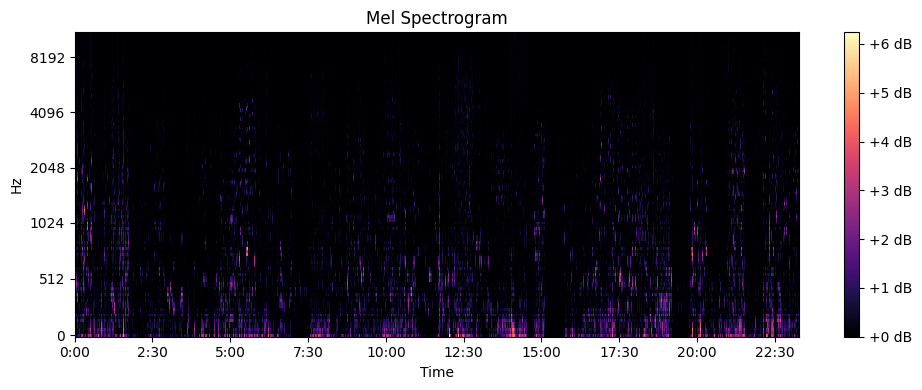

In [ ]:

audio, sr = librosa.load("/content/drive/MyDrive/archive/reconstructed_runs/sub-001_task-Training_run-03_audio.wav", sr=SR)

cochlear = compute_cochleogram(audio)



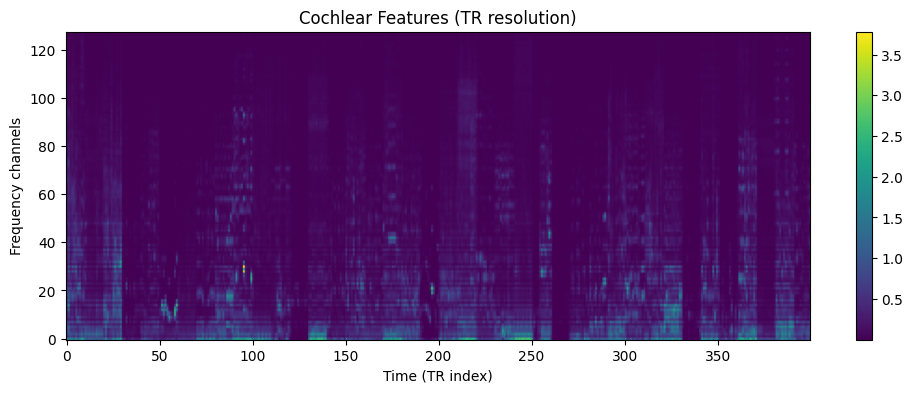

In [ ]:
coch_TR = downsample_to_TR(cochlear)

plt.figure(figsize=(12,4))
plt.imshow(coch_TR.T, aspect='auto', origin='lower')
plt.title("Cochlear Features (TR resolution)")
plt.xlabel("Time (TR index)")
plt.ylabel("Frequency channels")
plt.colorbar()
plt.show()

In [ ]:
print(cochlear.shape)
print(coch_TR.shape)

(128, 60137)
(400, 128)


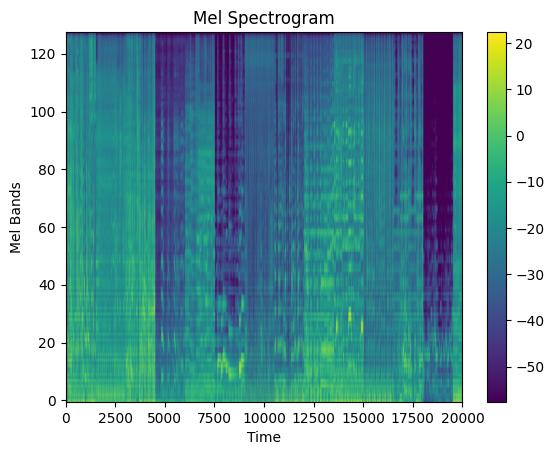

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

# Load audio
y, sr = librosa.load("/content/drive/MyDrive/archive/reconstructed_runs/sub-001_task-Training_run-03_audio.wav", sr=16000,duration = 200)

# Mel spectrogram
mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=400,        # 25 ms
    hop_length=160,   # 10 ms
    n_mels=128,
    fmin=100,
    fmax=8000
)

# Log scale
mel_spec_db = librosa.power_to_db(mel_spec)

# Plot
plt.imshow(mel_spec_db, aspect='auto', origin='lower')
plt.title("Mel Spectrogram")
plt.xlabel("Time")
plt.ylabel("Mel Bands")
plt.colorbar()
plt.show()

In [ ]:
!pip install gammatone

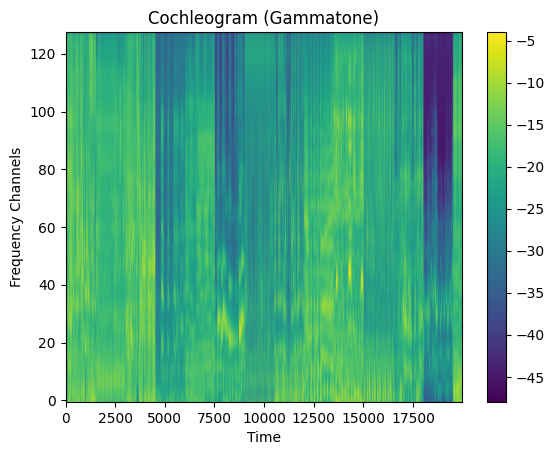

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from gammatone.gtgram import gtgram

# Load audio
y, sr = librosa.load("/content/drive/MyDrive/archive/reconstructed_runs/sub-001_task-Training_run-03_audio.wav", sr=16000, duration = 200)

# Cochleogram (gammatone)
cochlea = gtgram(
    y,
    sr,
    window_time=0.025,   # 25 ms
    hop_time=0.010,      # 10 ms
    channels=128,
    f_min=100
)

# Log compression (optional)
cochlea_log = np.log(cochlea + 1e-8)
cochl_db = librosa.power_to_db(cochlea)

# Plot
plt.imshow(cochl_db, aspect='auto', origin='lower')
plt.title("Cochleogram (Gammatone)")
plt.xlabel("Time")
plt.ylabel("Frequency Channels")
plt.colorbar()
plt.show()

In [ ]:
import pandas as pd

print("Cochleogram (Gammatone):")
display(pd.DataFrame(cochl_db))

print("\nMel Spectrogram (dB):")
display(pd.DataFrame(mel_spec_db))

Cochleogram (Gammatone):


,0,1,2,3,4,5,6,7,8,9,...,19988,19989,19990,19991,19992,19993,19994,19995,19996,19997
0,-14.602882,-12.851113,-12.820743,-14.569772,-15.908137,-15.133138,-14.642714,-14.453794,-14.269596,-12.985683,...,-10.736317,-8.378673,-8.047774,-9.106739,-11.650115,-12.615441,-13.505759,-13.273012,-12.540773,-13.363052
1,-14.447158,-12.771453,-12.700205,-14.387007,-15.756425,-15.469097,-14.942175,-14.557699,-13.998193,-12.349909,...,-9.720387,-8.133301,-8.294329,-10.145026,-12.150141,-12.332960,-12.379037,-12.427925,-11.971406,-12.547336
2,-14.602014,-12.828962,-12.797693,-14.746984,-16.666227,-16.289368,-15.701070,-15.318317,-14.560429,-12.589526,...,-9.466555,-8.415139,-8.632093,-10.302807,-11.100207,-11.857425,-11.671540,-11.805511,-11.631097,-12.243853
3,-14.519660,-13.025323,-13.218425,-16.245261,-17.586585,-16.811237,-16.572133,-16.584528,-15.741788,-12.949823,...,-10.111729,-9.071719,-9.159197,-10.420335,-10.856191,-11.933899,-11.627029,-11.682721,-11.864392,-12.519985
4,-14.453744,-13.473480,-13.894531,-17.621915,-17.772759,-17.074091,-17.295191,-17.612561,-17.016050,-12.962474,...,-10.775979,-9.703294,-9.752374,-10.993560,-11.186826,-12.543202,-11.783123,-11.544788,-11.887173,-12.542252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,-23.964242,-23.424253,-23.422266,-23.737120,-24.527841,-24.370738,-24.174446,-20.839485,-17.864495,-16.230776,...,-17.558700,-17.754992,-20.605621,-20.620911,-20.772850,-21.025563,-21.169051,-21.460980,-20.693348,-20.467361
124,-23.684757,-23.105637,-23.270543,-23.523167,-24.198134,-24.118312,-24.138517,-20.816991,-17.747807,-16.265691,...,-17.766356,-17.949734,-21.026846,-21.001193,-21.147933,-21.183769,-21.103613,-21.470682,-20.763470,-20.640740
125,-23.648532,-23.059184,-23.391368,-23.502513,-24.225410,-24.180985,-24.338535,-20.988396,-17.876746,-16.475162,...,-18.054736,-18.202526,-21.361820,-21.359746,-21.527415,-21.446636,-21.281719,-21.677809,-21.024134,-20.926082
126,-23.600186,-23.052226,-23.514265,-23.639297,-24.269072,-24.241272,-24.379250,-20.920975,-17.942076,-16.618234,...,-18.193397,-18.305220,-21.533179,-21.557804,-21.774543,-21.653213,-21.483821,-21.853810,-21.181492,-21.048430



Mel Spectrogram (dB):


,0,1,2,3,4,5,6,7,8,9,...,19991,19992,19993,19994,19995,19996,19997,19998,19999,20000
0,-3.823800,8.237629,1.147291,-4.029599,-16.316656,1.095080,-2.491852,-0.503259,1.472977,1.579957,...,2.820083,10.541240,-3.199581,6.179670,9.818988,3.732572,8.562297,-2.133022,3.942391,3.086736
1,-12.796549,-0.312093,-8.306970,-13.342286,-8.212871,-7.563353,-9.898347,-18.520834,-11.681053,-25.190699,...,7.110952,6.267136,-3.714357,-0.681173,6.655014,5.435748,4.498007,-16.040836,-5.112183,-1.311106
2,-10.031940,2.452515,-5.542362,-10.577678,-5.448261,-4.798744,-7.133739,-15.756227,-8.916446,-22.426090,...,9.875561,9.031743,-0.949749,2.083435,9.419622,8.200356,7.262616,-13.276226,-2.347575,1.453502
3,-13.626188,-2.748819,-3.012746,-6.866019,-31.793541,-2.088606,-1.814309,-3.930934,-2.956566,-2.296679,...,5.385773,1.451367,0.675195,-8.517626,7.256978,2.320939,0.988694,-0.939648,-2.440503,-1.568027
4,-14.969243,-4.091873,-4.355801,-8.209074,-33.136597,-3.431660,-3.157363,-5.273988,-4.299620,-3.639733,...,4.042718,0.108313,-0.667859,-9.860680,5.913924,0.977885,-0.354360,-2.282702,-3.783557,-2.911081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,-34.417473,-31.367573,-31.350616,-31.378252,-31.310463,-32.867847,-32.115059,-31.545687,-29.982918,-20.050625,...,-29.441517,-26.356514,-26.804390,-27.692501,-28.307716,-28.772644,-23.609407,-21.242191,-25.734291,-26.119328
124,-32.759747,-30.442928,-30.686472,-26.513433,-29.622576,-31.824055,-29.897045,-28.643116,-30.789415,-21.130884,...,-26.099522,-25.534952,-27.822758,-22.018738,-24.248039,-22.587688,-29.824783,-26.494839,-30.665634,-27.817308
125,-32.817699,-27.229425,-30.446220,-27.692162,-32.851101,-28.430809,-36.390488,-35.491482,-27.497843,-19.217932,...,-25.698898,-28.342134,-31.855621,-29.703381,-31.254683,-31.595085,-30.807022,-26.641428,-25.961918,-27.933392
126,-39.089424,-35.267529,-34.909737,-36.813683,-40.449505,-38.505001,-36.894764,-36.251934,-37.379597,-20.936546,...,-31.114180,-30.485317,-31.666506,-34.511635,-32.951443,-31.981218,-28.210487,-25.116064,-25.087168,-31.238937
